# Data Exploration & Preparation (CA1)
## Topic: Salary Survey Data Analysis

### **Main goal:** Load the salary dataset, do a quick overview, clean the data, and perform an exploratory data analysis (EDA).

### GitHub Classroom Repository:
### https://github.com/SemenyukAndrey/Data-Exploration-Preparation-CA1---Salary-Survey-Dataset-.git


## 1. Importing Libraries
### Before we start, we need to import all the necessary libraries to work with the data and visualize it.

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Loading the Dataset
### Let's read the data from the 'Salary_Survey.csv' file. While loading, we will also provide a list of weird values like "n.a.", "?", "n/a", "NA", and "--" so Pandas can read them as missing values (NaN).

In [20]:
# Read the csv file and handle missing values
missing_values=["n.a.", "?","n/a","n","NA","--"]
df=pd.read_csv('Salary_Survey.csv',na_values=missing_values)

# Show the first 5 rows to check if it loaded correctly
df.head()

,Timestamp,How old are you?,What industry do you work in?,Job title,"If your job title needs additional context, please clarify here:","What is your annual salary? (You'll indicate the currency in a later question. If you are part-time or hourly, please enter an annualized equivalent -- what you would earn if you worked the job 40 hours a week, 52 weeks a year.)","How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits.",Please indicate the currency,"If ""Other,"" please indicate the currency here:","If your income needs additional context, please provide it here:",...,How many years of professional work experience do you have overall?,How many years of professional work experience do you have in your field?,What is your highest level of education completed?,What is your gender?,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,NaN,"55,000",0.0,USD,NaN,NaN,...,5-7 years,5-7 years,Master's degree,Woman,NaN,NaN,NaN,NaN,NaN,NaN
1,4/27/2021 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,NaN,"54,600",4000.0,GBP,NaN,NaN,...,8 - 10 years,5-7 years,College degree,Non-binary,NaN,NaN,NaN,NaN,NaN,NaN
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,NaN,"34,000",NaN,USD,NaN,NaN,...,2 - 4 years,2 - 4 years,College degree,Woman,NaN,NaN,NaN,NaN,NaN,NaN
3,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,NaN,"62,000",3000.0,USD,NaN,NaN,...,8 - 10 years,5-7 years,College degree,Woman,NaN,NaN,NaN,NaN,NaN,NaN
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,NaN,"60,000",7000.0,USD,NaN,NaN,...,8 - 10 years,5-7 years,College degree,Woman,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# Check of missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Timestamp                                                                                                                                                                                                                                  93
How old are you?                                                                                                                                                                                                                           93
What industry do you work in?                                                                                                                                                                                                             167
Job title                                                                                                                                                                                                                                  94
If your job title nee

## 3. Basic Data Overview
### Now let's check the general structure of our data, the data types, and the size of the dataframe.

In [22]:
# Get info about data types and non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28178 entries, 0 to 28177
Data columns (total 23 columns):
 #   Column                                                                                                                                                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                                                                                                                                                --------------  -----  
 0   Timestamp                                                                                                                                                                                                                             28085 non-null  str    
 1   How old are you?                                                                                                        

In [23]:
# Check the number of rows and columns
df.shape

(28178, 23)

In [24]:
# Calculate main statistics for numeric columns
df.describe()

,"How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits.",Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
count,2.078000e+04,0.0,0.0,0.0,0.0,0.0,0.0
mean,1.815342e+04,NaN,NaN,NaN,NaN,NaN,NaN
std,8.337722e+05,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN
50%,2.000000e+03,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000e+04,NaN,NaN,NaN,NaN,NaN,NaN
max,1.200000e+08,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data Cleaning
### In this section, we will make our data ready for analysis. We need to drop empty or useless columns, rename long column names, remove duplicates, change the salary columns to numbers, and fill in the missing values.

In [25]:
# Drop useless columns that are completely empty (Unnamed)

df = df.drop(['Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22'], axis=1)

In [26]:
# Rename columns to make them shorter and easier to work with

df = df.rename(columns={
    'How old are you?': 'Age',
    'What industry do you work in?': 'Industry',
    'If your job title needs additional context, please clarify here:': 'Job title addition',
    "What is your annual salary? (You'll indicate the currency in a later question. If you are part-time or hourly, please enter an annualized equivalent -- what you would earn if you worked the job 40 hours a week, 52 weeks a year.)": 'Annual salary', 
    'How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits.': 'Bonus average year',
    'Please indicate the currency': 'Currency',
    'If "Other," please indicate the currency here: ': 'Other',
    'If your income needs additional context, please provide it here:': 'Income additional',
    'What country do you work in?': 'Country',
    "If you're in the U.S., what state do you work in?": 'State',
    'What city do you work in?': 'City',
    'How many years of professional work experience do you have overall?': 'Experience',
    'How many years of professional work experience do you have in your field?': 'Work experience',
    'What is your highest level of education completed?': 'Education',
    'What is your gender?': 'Gender'
    
})


In [27]:
# Find and count duplicate rows
duplicated_rows=df[df.duplicated()]
print(duplicated_rows.shape)

(92, 17)


In [28]:
# Drop duplicate rows
df=df.drop_duplicates()
df.shape

(28086, 17)

In [29]:
# Clean the 'Annual salary' column:
# Convert to string, remove commas, extract numbers, and convert to float

df['Annual salary'] = (
    df['Annual salary']
    .astype(str)
    .str.replace(',', '')
    .str.extract('(\d+\.?\d*)')[0]
    .astype(float)
)

In [30]:
# Fill missing values in numeric columns with the median

df['Annual salary'] = df['Annual salary'].fillna(df['Annual salary'].median())
df['Bonus average year'] = df['Bonus average year'].fillna(df['Bonus average year'].median())

In [31]:
# Fill missing values in categorical columns using the mode (the most frequent value)

categorical_cols = ['Timestamp', 'Age', 'Industry', 'Job title', 'Job title addition', 'Currency', 'Other', 'Income additional', 'Country', 'State', 
                   'City', 'Experience', 'Work experience', 'Education', 'Gender']

for col in categorical_cols:
    most_common = df[col].mode()[0]
    df[col] = df[col].fillna(most_common)

In [32]:
# Final check to make sure there are no missing values left

df.isnull().sum()

Timestamp             0
Age                   0
Industry              0
Job title             0
Job title addition    0
Annual salary         0
Bonus average year    0
Currency              0
Other                 0
Income additional     0
Country               0
State                 0
City                  0
Experience            0
Work experience       0
Education             0
Gender                0
dtype: int64

In [33]:
# Show the cleaned data

df.head()

,Timestamp,Age,Industry,Job title,Job title addition,Annual salary,Bonus average year,Currency,Other,Income additional,Country,State,City,Experience,Work experience,Education,Gender
0,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,Fundraising,55000.0,0.0,USD,INR,Hourly,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman
1,4/27/2021 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,Fundraising,54600.0,4000.0,GBP,INR,Hourly,United Kingdom,California,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,Fundraising,34000.0,2000.0,USD,INR,Hourly,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman
3,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,Fundraising,62000.0,3000.0,USD,INR,Hourly,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,Fundraising,60000.0,7000.0,USD,INR,Hourly,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman


## 5. Exploratory Data Analysis (EDA)
### Let's make some plots to understand the salary distribution and find any weird values (outliers).

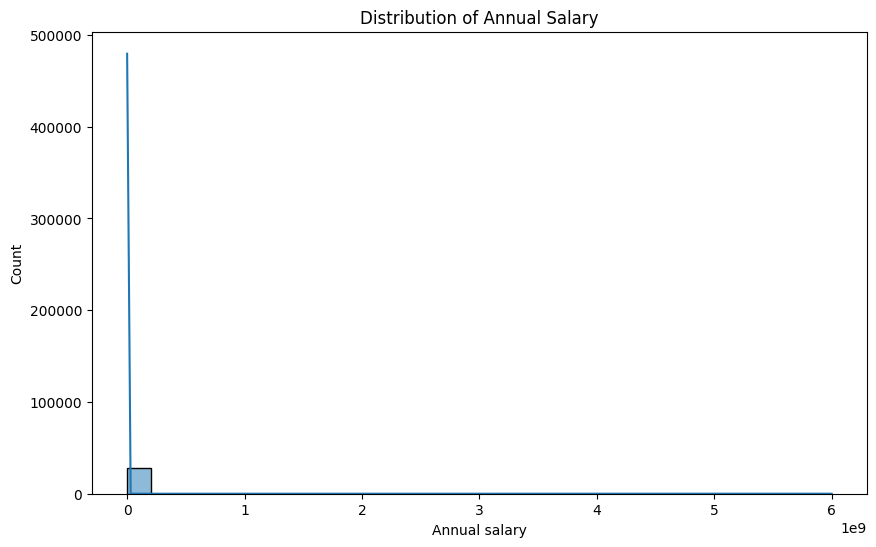

In [34]:
# Plot a histogram for the annual salary distribution

plt.figure(figsize=(10,6))
sns.histplot(df['Annual salary'], bins=30, kde=True)
plt.title("Distribution of Annual Salary")
plt.show()

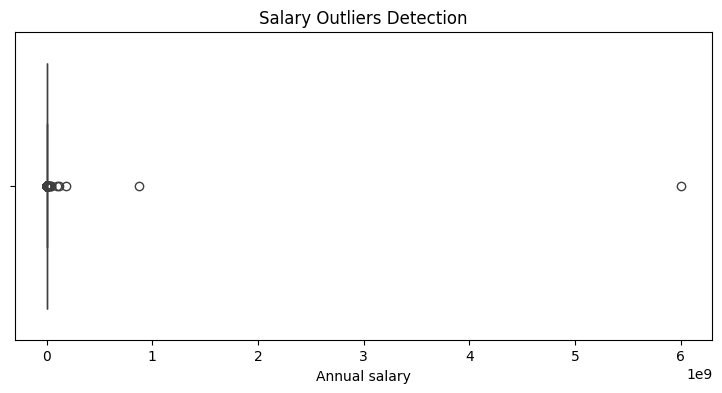

In [35]:
# Plot a boxplot to find outliers in the annual salary

plt.figure(figsize=(9,4))
sns.boxplot(x=df['Annual salary'])
plt.title("Salary Outliers Detection")
plt.xlabel("Annual salary")
plt.show()

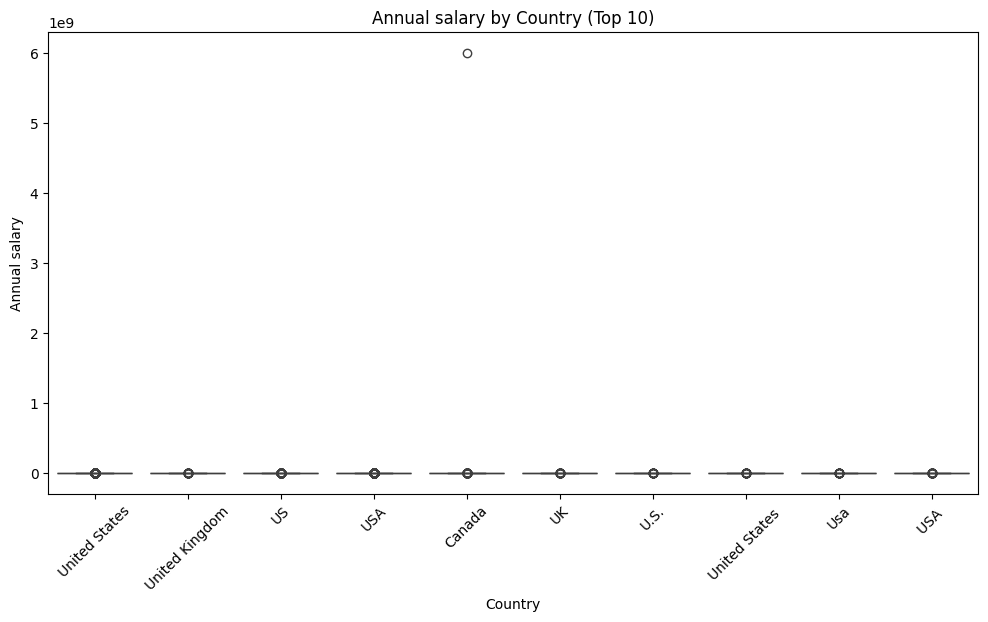

In [36]:
# Plot a boxplot to find outliers in annual bonuses

plt.figure(figsize=(12,6))
top_countries = df['Country'].value_counts().head(10).index
sns.boxplot(data=df[df['Country'].isin(top_countries)], x='Country', y='Annual salary')
plt.title("Annual salary by Country (Top 10)")
plt.xticks(rotation=45)
plt.show()

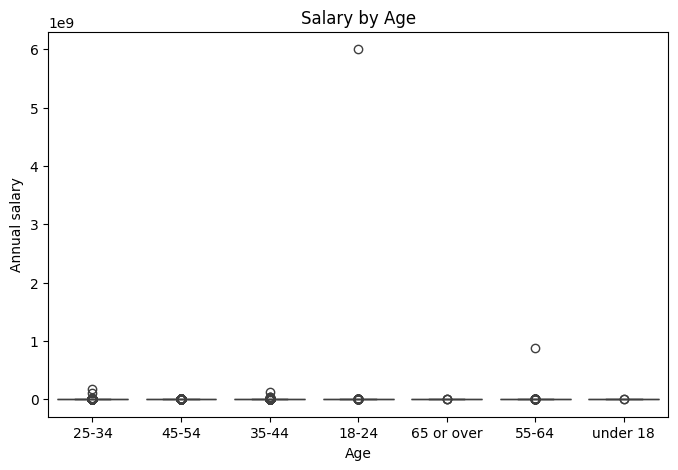

In [38]:
#Creating a boxplot to compare the columns 'Age' and 'Annual salary

plt.figure(figsize=(8,5))
sns.boxplot(x='Age', y='Annual salary', data=df)
plt.title('Salary by Age')
plt.show()

<Axes: xlabel='Bonus average year'>

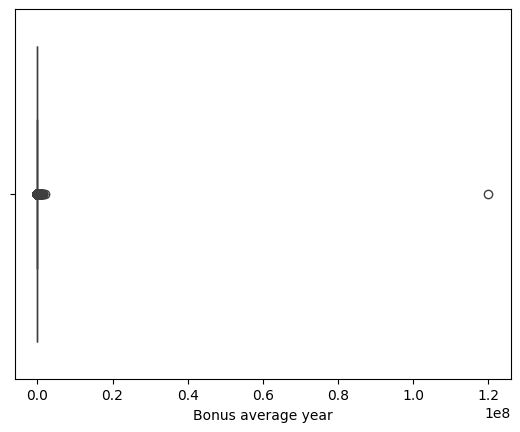

In [39]:
#Creating a boxplot to visualize outliers in the 'Bonus average year' column

sns.boxplot(x=df['Bonus average year'])

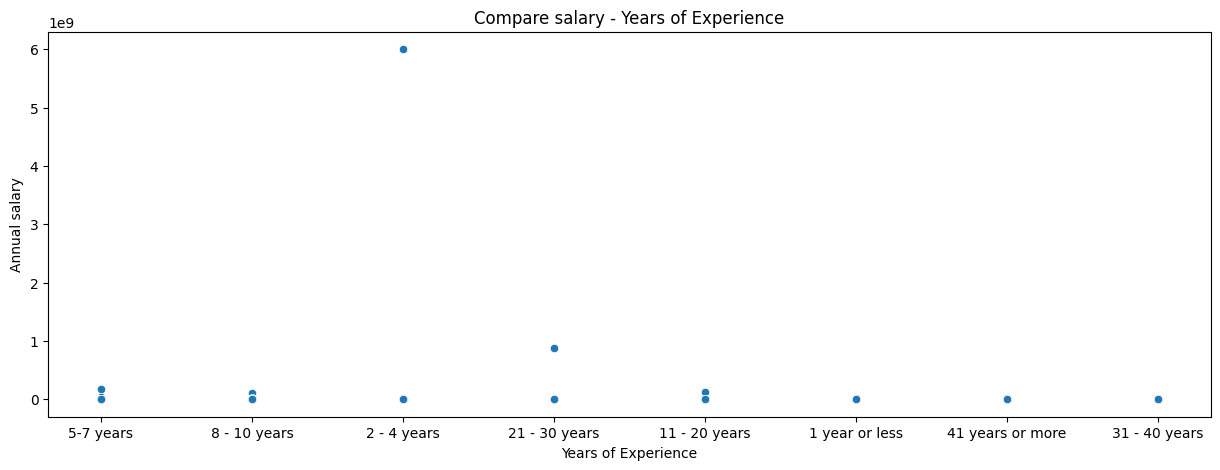

In [40]:
#Compare salary - Years of Experience

plt.figure(figsize=(15,5))
sns.scatterplot(x='Experience', y='Annual salary', data=df)
plt.title("Compare salary - Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Annual salary")
plt.savefig("Compare salary - Years of Experience.png", dpi=300, bbox_inches='tight')
plt.show()

# 6. Correlation & Insights

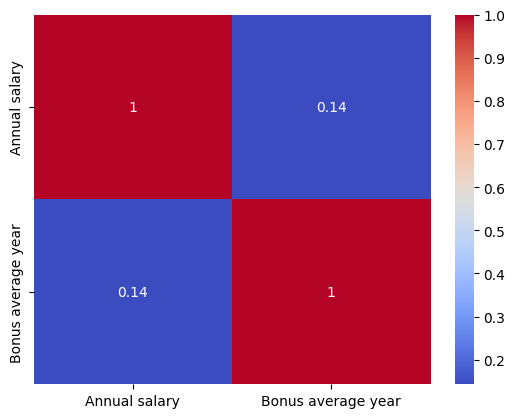

In [41]:
#We use a heatmap to visualize the correlation between numerical features in the dataset.

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


Most variables show weak correlation with Annual Salary, suggesting that salary may depend on categorical factors such as job title or experience.

## Conclusion
### In this task, we successfully loaded and analyzed the dataset. We did a lot of cleaning: dropped useless columns and duplicates, renamed columns to make them easier to read, and fixed the numeric data by removing commas. We also filled all the missing values (using the median for numbers and the mode for text data). Finally, our charts showed the salary distribution and highlighted some clear outliers that we can work with later to build better machine learning models.